# Convergence Study of EFIT

## Overview

EFIT stores a reconstruction as its final state. How it got there -- the
chi-square, the flux increment and the magnetic axis at every Picard step -- is
printed to the terminal and then lost. That is not enough to tell monotonic
convergence from a plateau, an oscillation or an axis hopping between grid
cells (#1027), and every numerical study so far has re-parsed the log to find
out.

`vaft.code.efit` now keeps that trajectory as an object,
`EFITIterationHistory`, and this notebook is the standard way to read one. It
works on a **saved** history, so nothing here runs EFIT:

- a run asks for one with `EFITConfig(iteration_history="summary")`, which
  writes `efit_iteration_history.json` beside the outputs and returns it as
  `EFITResult.iteration_history`;
- any finished run can be read afterwards with
  `iteration_history_from_workdir(workdir)`, whether or not it asked.

This is phase 1 of issue #1038: what EFIT already prints, with no EFIT source
change. Per-iteration diagnostic residuals and psi/boundary snapshots need an
instrumented EFIT and come later (see the last section).

## Study setup

Two histories of shot 39915 ship with the repository, produced by
`workflow/efit_numerics/make_iteration_history_sample.py` from the packaged
sample's own k-files on the packaged 129x129 table. They differ in `NXITER`,
the number of inner equilibrium steps per outer (current-profile) iteration:
the routine run uses EFIT's default of 1, the other 3. `MXITER` moves with it,
from 100 to 514 // 3 = 171, the largest cap the cumulative counter cannot
overrun EFIT's 515-entry iteration arrays with (#171); neither run comes near
its cap, so the comparison is one of `NXITER`.

To inspect a run of your own instead, set `VAFT_EFIT_WORKDIR` to its work
directory before running the notebook.

In [ ]:
import os

import matplotlib.pyplot as plt
import numpy as np

from vaft.code.efit import (
    compare_iteration_histories,
    iteration_history_from_workdir,
    plot_iteration_convergence,
    read_iteration_history,
)
from vaft.data.resources import data_path

routine = read_iteration_history(data_path("efit/iteration_history/39915_nxiter1.json"))
inner3 = read_iteration_history(data_path("efit/iteration_history/39915_nxiter3.json"))
histories = {"NXITER=1": routine, "NXITER=3": inner3}

own = os.environ.get("VAFT_EFIT_WORKDIR")
if own:
    histories = {"this run": iteration_history_from_workdir(own)}
    routine = histories["this run"]

for label, history in histories.items():
    print(f"{label}: {len(history)} slices at {np.round(history.times * 1e3, 1).tolist()} ms")

NXITER=1: 9 slices at [316.0, 317.0, 318.0, 319.0, 320.0, 323.0, 325.0, 326.0, 331.0] ms
NXITER=3: 9 slices at [316.0, 317.0, 318.0, 319.0, 320.0, 323.0, 325.0, 326.0, 331.0] ms


## Run provenance and numerical configuration

A trajectory means nothing without the settings that produced it, so these come
first. `numerics` is the run's resolved `EFITNumericsConfig`: `None` means the
k-file wrote no key and EFIT's own default applied. `ERROR` is where the inner
loop stops; `ERRMIN` gates the chi-square exit of the outer loop (EFIT's
default is 1e-2).

In [ ]:
rows = ("relaxation", "max_iterations", "inner_iterations", "error_tolerance", "error_minimum",
        "chi_squared_target", "convergence_mode")
print(f"{'':20s}" + "".join(f"{label:>24s}" for label in histories))
for key in rows:
    print(f"{key:20s}" + "".join(f"{str(h.provenance['numerics'].get(key)):>24s}" for h in histories.values()))
for key in ("uncertainty_mode", "args", "scientific_sha256", "vaft_revision"):
    print(f"{key:20s}" + "".join(f"{str(h.provenance.get(key))[:22]:>24s}" for h in histories.values()))
print(f"{'table':20s}" + "".join(f"{str((h.provenance.get('table') or {}).get('era'))[:22]:>24s}"
                                 for h in histories.values()))

                                    NXITER=1                NXITER=3
relaxation                               1.0                     1.0
max_iterations                           100                     171
inner_iterations                        None                       3
error_tolerance                        1e-05                   1e-05
error_minimum                           None                    None
chi_squared_target                      None                    None
convergence_mode                        None                    None
uncertainty_mode               legacy_weight           legacy_weight
args                                 ['129']                 ['129']
scientific_sha256     9bbb69a6a858bede8184c7  323e8ddf22b344078c7dd7
vaft_revision         e4b824aabbfbd717f9ae4a  e4b824aabbfbd717f9ae4a
table                  vest-pre-43017-pf1906   vest-pre-43017-pf1906


## What the iteration counter is

EFIT prints and stores one counter, `nitera`, incremented inside the inner
loop: it is cumulative over outer and inner iterations. The outer and inner
counters are recorded only where they follow from it -- with `NXITER=1` -- and
the history says so in its own words rather than leaving it to be assumed.

In [ ]:
for label, history in histories.items():
    print(f"{label}:")
    for key in ("nxiter", "nxiter_source", "outer_inner"):
        print(f"  {key}: {history.numbering[key]}")

NXITER=1:
  nxiter: 1
  nxiter_source: k-files
  outer_inner: derived: with NXITER=1 every outer iteration is exactly one inner step, so outer = cumulative and inner = 1
NXITER=3:
  nxiter: 3
  nxiter_source: k-files
  outer_inner: not recorded: EFIT prints only the cumulative counter, and its inner loop can leave before NXITER steps once the increment falls below ERROR, so the outer/inner boundaries are not in its output


## Overall Picard convergence

One line per slice, against the cumulative counter. Two things to keep in mind
when reading it:

- the chi-square is the one EFIT prints per step. Under the routine legacy
  uncertainty model it is ~1e-8 on this shot, because the magnetic channels
  are given sigmas so large that they contribute almost nothing (#891): a
  tiny value here is not a good fit. The printed value can also differ from
  the a-file's `chisq`, which is EFIT's own final answer
  (`workflow/efit_numerics/README.md`);
- the flux increment `errorm` is how far the last step moved psi, not a
  Grad-Shafranov residual. Its falling below a threshold says the iteration
  stopped moving, not that force balance holds (#924).

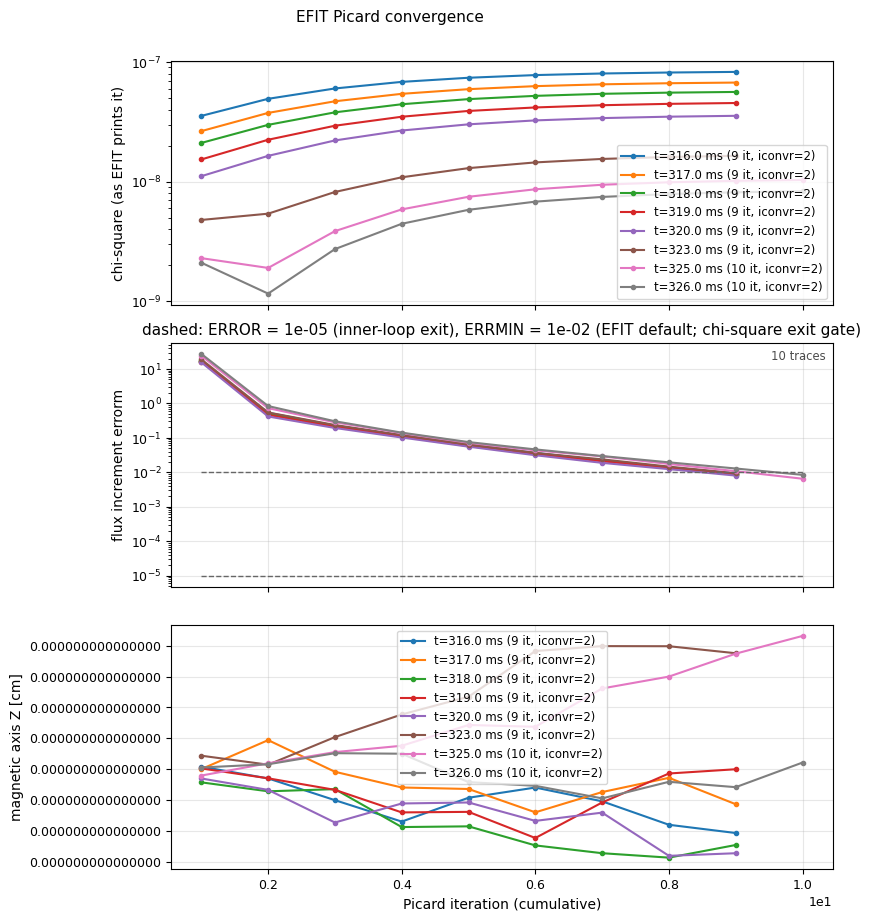

In [ ]:
figure, axes = plot_iteration_convergence(routine)
figure.set_size_inches(9, 9)
plt.show()

Per slice, the same trajectory as numbers: how many steps it took, how it
ended, and how far the increment fell. These are descriptions; none of them is
an acceptance criterion.

In [ ]:
print(f"{'t [ms]':>7s} {'steps':>5s} {'exit':>21s} {'first err':>10s} {'last err':>10s} {'reduction':>9s}  notes")
for item in routine:
    if item.iterations:
        error = item.error
        print(f"{item.time * 1e3:7.1f} {item.iterations_n:5d} {str(item.exit_path):>21s} "
              f"{error[0]:10.3e} {error[-1]:10.3e} {error[-1] / error[0]:9.1e}")
    else:
        print(f"{item.time * 1e3:7.1f} {0:5d} {str(item.exit_path):>21s} {'':>10s} {'':>10s} {'':>9s}  "
              + "; ".join(item.notes))

 t [ms] steps                  exit  first err   last err reduction  notes
  316.0     9              iconvr=2  1.731e+01  9.208e-03   5.3e-04
  317.0     9              iconvr=2  1.716e+01  8.676e-03   5.1e-04
  318.0     9              iconvr=2  1.701e+01  8.524e-03   5.0e-04
  319.0     9              iconvr=2  1.642e+01  8.958e-03   5.5e-04
  320.0     9              iconvr=2  1.559e+01  8.023e-03   5.1e-04
  323.0     9              iconvr=2  1.908e+01  9.405e-03   4.9e-04
  325.0    10              iconvr=2  2.412e+01  6.505e-03   2.7e-04
  326.0    10              iconvr=2  2.738e+01  8.436e-03   3.1e-04
  331.0     0                  None                                  EFIT ran no Picard step on this slice: its m-file arrays ({'cerror': 1, 'cchisq': 1, 'czmaxi': 1}) hold a single zero and were not read as iterations


The last slice ran no Picard step at all. EFIT still wrote an m-file for it,
with a single zero in each per-iteration array; the history keeps the slice
and says in `notes` why that zero was not read as an iteration. The log is the
universe of slices; a slice missing from it is reported, never silently
filled.

## Magnetic-axis trajectory

`axis_z` is the axis height at every step -- the quantity that shows an axis
hopping between grid cells (#1027). Shot 39915 is fitted up-down symmetric, so
here it stays at round-off (~1e-17 m) for every step of every slice: a flat
trace is the expected answer for this sample, and the panel is the place to
look first on a shot where it is not.

In [ ]:
for item in routine:
    if item.iterations:
        print(f"t={item.time * 1e3:5.1f} ms  max |axis_z| over the iteration = {np.nanmax(np.abs(item.axis_z)):.1e} m")

t=316.0 ms  max |axis_z| over the iteration = 2.1e-17 m
t=317.0 ms  max |axis_z| over the iteration = 1.4e-17 m
t=318.0 ms  max |axis_z| over the iteration = 2.9e-17 m
t=319.0 ms  max |axis_z| over the iteration = 2.2e-17 m
t=320.0 ms  max |axis_z| over the iteration = 2.8e-17 m
t=323.0 ms  max |axis_z| over the iteration = 4.0e-17 m
t=325.0 ms  max |axis_z| over the iteration = 4.3e-17 m
t=326.0 ms  max |axis_z| over the iteration = 9.5e-18 m


## Comparing two numerical configurations

The same slice under `NXITER=1` and `NXITER=3`, on one cumulative axis. With
three inner steps per outer iteration the solve spends more steps in total and
drives the increment further down before the chi-square exit fires -- that is
the trade #924 measures across the whole reference set.

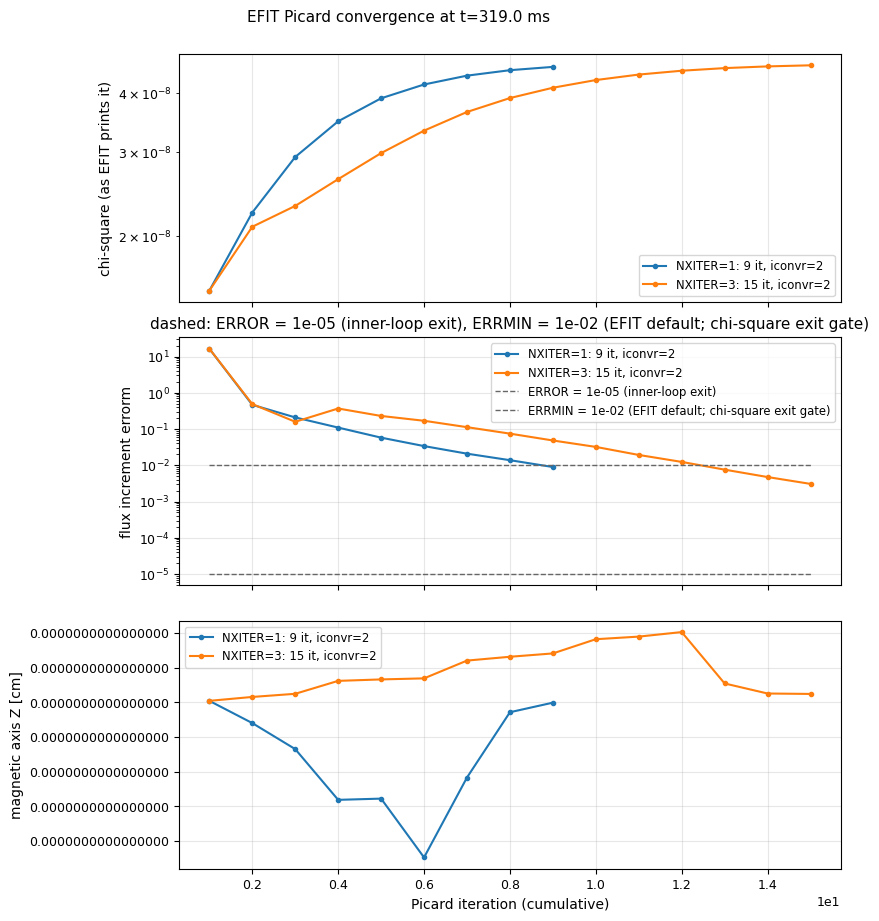

t=316.0 ms  steps   9 ->  15   last increment 9.21e-03 -> 3.46e-03
t=317.0 ms  steps   9 ->  15   last increment 8.68e-03 -> 3.12e-03
t=318.0 ms  steps   9 ->  15   last increment 8.52e-03 -> 3.39e-03
t=319.0 ms  steps   9 ->  15   last increment 8.96e-03 -> 3.07e-03
t=320.0 ms  steps   9 ->  15   last increment 8.02e-03 -> 2.80e-03
t=323.0 ms  steps   9 ->  15   last increment 9.40e-03 -> 2.58e-03
t=325.0 ms  steps  10 ->  15   last increment 6.50e-03 -> 3.10e-03
t=326.0 ms  steps  10 ->  15   last increment 8.44e-03 -> 3.14e-03


In [ ]:
if len(histories) > 1:
    figure, axes = compare_iteration_histories(histories, 0.319)
    figure.set_size_inches(9, 9)
    plt.show()
    for time in routine.times:
        a, b = routine.at_time(time), inner3.at_time(time)
        if a.iterations and b.iterations:
            print(f"t={time * 1e3:5.1f} ms  steps {a.iterations_n:3d} -> {b.iterations_n:3d}   "
                  f"last increment {a.error[-1]:.2e} -> {b.error[-1]:.2e}")

## What later phases add (issue #1038)

This notebook reads only what EFIT prints and what its m-file stores. The rest
of the issue needs EFIT itself to write per-iteration output, and these
sections will grow with it:

- **diagnostic convergence** -- measured, reconstructed, sigma and weight per
  channel at every step, family chi-square (Bp probes, flux loops, Ip,
  diamagnetic flux) and a channel x iteration residual map;
- **state snapshots** -- psi(R, Z), the axis and the boundary per step, and
  the flux change between steps;
- the combined state/measurement view that asks whether an axis oscillation
  and a residual oscillation share a period.

`EFITConfig(iteration_history=...)` refuses those levels today rather than run
them as `"none"`.